<a href="https://colab.research.google.com/github/adapasriram/Projectss/blob/main/adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/census_income.csv")

In [3]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [5]:
df.duplicated().sum()

np.int64(24)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.replace('?', ' ', inplace=True)

In [9]:
df.replace('?', np.nan, inplace=True)

In [10]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
df.replace('?', np.nan, inplace=True)

for col in df.columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1249/2620788029.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1249/2620788029.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [12]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [13]:
num_cols = df.select_dtypes(include=np.number).columns

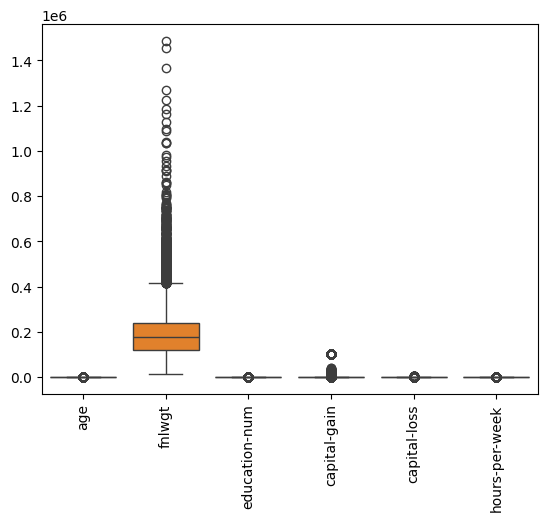

In [14]:
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col, "outliers:", ((df[col] < lower) | (df[col] > upper)).sum())

    # Handle by capping
    df[col] = df[col].clip(lower, upper)

age outliers: 142
fnlwgt outliers: 993
education-num outliers: 1193
capital-gain outliers: 2712
capital-loss outliers: 1519
hours-per-week outliers: 9002


In [15]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[col] < Q1 - 1.5*IQR) |
                (df[col] > Q3 + 1.5*IQR)).sum()

    print(col, ":", outliers)

age : 142
fnlwgt : 993
education-num : 1193
capital-gain : 2712
capital-loss : 1519
hours-per-week : 9002


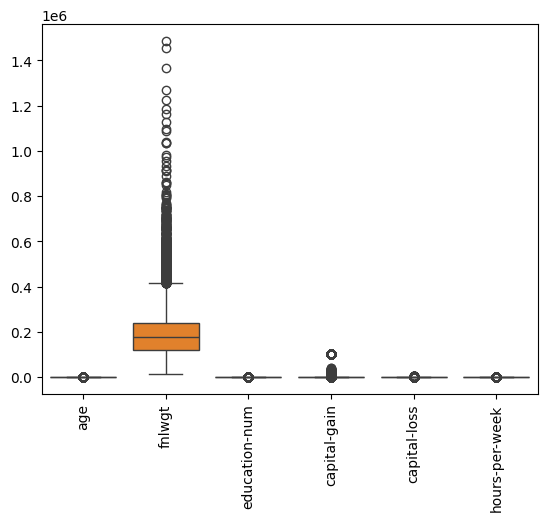

In [16]:
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

In [19]:
from sklearn.ensemble import AdaBoostClassifier

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education-num   32537 non-null  int64 
 5   marital-status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital-gain    32537 non-null  int64 
 11  capital-loss    32537 non-null  int64 
 12  hours-per-week  32537 non-null  int64 
 13  native-country  32537 non-null  object
 14  annual_income   32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


In [17]:
from sklearn.preprocessing import LabelEncoder

SyntaxError: expected ':' (3715630440.py, line 2)

In [21]:
le = LabelEncoder()
for i in df.columns:
  if(df[i].dtype == "object"):
    df[i] = le.fit_transform(df[i])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int64
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int64
 4   education-num   32537 non-null  int64
 5   marital-status  32537 non-null  int64
 6   occupation      32537 non-null  int64
 7   relationship    32537 non-null  int64
 8   race            32537 non-null  int64
 9   sex             32537 non-null  int64
 10  capital-gain    32537 non-null  int64
 11  capital-loss    32537 non-null  int64
 12  hours-per-week  32537 non-null  int64
 13  native-country  32537 non-null  int64
 14  annual_income   32537 non-null  int64
dtypes: int64(15)
memory usage: 4.0 MB


In [ ]:
# Model Building ->
# 1. Split the data into Independent(x) and Dependent(y)
# 2. Split the data into Training and Testing
# 3. Train the Model
# 4. Test the Model
# 5. Evaluation

In [ ]:
# Logistics, Decision Tree, Random Forest, Ada Boost

In [23]:
X = df.drop("annual_income", axis=1)
y = df["annual_income"]

In [28]:
X = pd.get_dummies(X)

In [29]:
y = y.map({"<=50K": 0, ">50K": 1})

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8126920712968654


In [37]:
model = AdaBoostClassifier()

model.fit(X_train, y_train)

AdaBoostClassifier()

In [36]:
model = AdaBoostClassifier()

In [ ]:
model

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.854179471419791
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4905
           1       0.76      0.60      0.67      1603

    accuracy                           0.85      6508
   macro avg       0.82      0.77      0.79      6508
weighted avg       0.85      0.85      0.85      6508



In [42]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

In [46]:
accuracy

0.7896435156730178